In [1]:
import numpy as np
import sympy as sp
from jetgp.full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import jetgp.utils as utils

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 20
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 25
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Domain bounds: x ∈ {domain_bounds[0]}, y ∈ {domain_bounds[1]}")

Configuration complete!
Number of training points: 20
Domain bounds: x ∈ (-5.0, 10.0), y ∈ (0.0, 15.0)


In [3]:
# Define symbolic Branin function
x_sym, y_sym = sp.symbols('x y')
a, b, c, r, s, t = 1.0, 5.1/(4*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8*sp.pi)
f_sym = a * (y_sym - b*x_sym**2 + c*x_sym - r)**2 + s*(1 - t)*sp.cos(x_sym) + s

# Compute symbolic gradients
grad_x_sym = sp.diff(f_sym, x_sym)
grad_y_sym = sp.diff(f_sym, y_sym)

# Convert to NumPy functions
true_function_np = sp.lambdify([x_sym, y_sym], f_sym, 'numpy')
grad_x_func = sp.lambdify([x_sym, y_sym], grad_x_sym, 'numpy')
grad_y_func = sp.lambdify([x_sym, y_sym], grad_y_sym, 'numpy')

def true_function(X, alg=np):
    """2D Branin function."""
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    gx = grad_x_func(x, y)
    gy = grad_y_func(x, y)
    return gx, gy

print("Branin function and analytical gradients defined!")

Branin function and analytical gradients defined!


In [4]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (
        xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (
        ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25,
             head_length=0.35, fc=color, ec=color)

print("Arrow clipping utility defined!")

Arrow clipping utility defined!


In [5]:
# 1. Generate points using Latin Hypercube
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples,
                    [b[0] for b in domain_bounds],
                    [b[1] for b in domain_bounds])

# 2. Compute gradient-aligned rays at each training point
rays_list = []
for i, (x, y) in enumerate(X_train):
    gx, gy = true_gradient(x, y)
    # Normalize to unit vector
    magnitude = np.sqrt(gx**2 + gy**2)
    ray = np.array([[gx/magnitude], [gy/magnitude]])
    rays_list.append(ray)

# 3. Compute function values at training points
y_func = true_function(X_train).reshape(-1, 1)

# 4. Compute directional derivatives using the chain rule
# For each point: d_ray = grad_x * ray[0] + grad_y * ray[1]
directional_derivs = []
for i, (x, y) in enumerate(X_train):
    gx, gy = true_gradient(x, y)
    ray_direction = rays_list[i].flatten()
    # Directional derivative = gradient · direction
    dir_deriv = gx * ray_direction[0] + gy * ray_direction[1]
    directional_derivs.append(dir_deriv)

# Stack all directional derivatives into a single array
directional_derivs_array = np.array(directional_derivs).reshape(-1, 1)

# 5. Package training data
# y_train_list should be a list of two arrays, each of shape [num_training_pts, 1]
y_train_list = [y_func, directional_derivs_array]
der_indices = [[[[1, 1]]]]

print(f"Training data generated!")
print(f"X_train shape: {X_train.shape}")
print(f"Function values shape: {y_func.shape}")
print(f"Directional derivatives shape: {directional_derivs_array.shape}")
print(f"Number of unique ray directions: {len(rays_list)}")
print("\nExample ray directions (first 3 points):")
for i in range(min(3, num_training_pts)):
    ray = rays_list[i].flatten()
    angle = np.arctan2(ray[1], ray[0]) * 180 / np.pi
    print(f"  Point {i}: [{ray[0]:+.4f}, {ray[1]:+.4f}] (angle: {angle:.1f}°)")

Training data generated!
X_train shape: (20, 2)
Function values shape: (20, 1)
Directional derivatives shape: (20, 1)
Number of unique ray directions: 20

Example ray directions (first 3 points):
  Point 0: [+0.9418, +0.3361] (angle: 19.6°)
  Point 1: [+0.9408, -0.3391] (angle: -19.8°)
  Point 2: [-0.6352, +0.7724] (angle: 129.4°)


In [6]:
# Convert rays_list to array format for GDDEGP
# Stack rays horizontally: each column is a ray
rays_array = np.hstack(rays_list)  # Shape: (2, num_training_pts)
derivative_locations = []
for i in range(len(der_indices)):
        for j in range(len(der_indices[i])):
            derivative_locations.append([i for i in range(len(X_train ))])

print(f"Rays array shape: {rays_array.shape}")
print("Initializing GDDEGP model...")

# Initialize GDDEGP model
gp_model = gddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    rays_list=[rays_array],
    der_indices=der_indices,
    derivative_locations=derivative_locations,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("GDDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Rays array shape: (2, 20)
Initializing GDDEGP model...
GDDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [-0.0930308  -1.24946515  1.8046176  -6.98599102]


In [7]:
# Create test grid
gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(gx, gy)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
N_test = X_test.shape[0]

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {N_test} points")


print("Making predictions...")
y_pred_full = gp_model.predict(
    X_test, params, calc_cov=False, return_deriv=False)
y_pred = y_pred_full[0,:]  # Function values only

# Compute ground truth and error
y_true = true_function(X_test, alg=np)
nrmse_val = utils.nrmse(y_true.flatten(), y_pred.flatten())

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse_val:.6f}")
abs_error = np.abs(y_true.flatten() - y_pred.flatten())
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Test grid: 25×25 = 625 points
Making predictions...

Model Performance:
  NRMSE: 0.000220
  Max absolute error: 0.478355
  Mean absolute error: 0.020303


In [8]:
# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Prepare rays for prediction at training points
rays_train = np.hstack(rays_list)  # Shape: (2, num_training_pts)

# Predict at training points with derivatives
y_pred_train_full = gp_model.predict(
    X_train, params, rays_predict = [rays_train], calc_cov=False, return_deriv=True
)

# Extract function values (first num_training_pts entries)
y_pred_train_func = y_pred_train_full[0,:]

print("Function value interpolation errors:")
print("=" * 80)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train_func[i] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train_func - y_func_values))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Directional derivative interpolation verification:")
print("=" * 80)
print("Note: Each training point has a DIFFERENT gradient-aligned direction")
print("=" * 80)

# Extract predicted derivatives (entries after function values)
y_pred_train_derivs = y_pred_train_full[1,:]

# Extract analytic derivatives from training data
analytic_derivs = y_train_list[1]

print(f"\nPrediction with derivatives shape: {y_pred_train_full.shape}")
print(f"Expected: {num_training_pts} function values + {num_training_pts} derivatives = {2 * num_training_pts}")
print(f"Predicted derivatives shape: {y_pred_train_derivs.shape}")
print(f"Analytic derivatives shape: {analytic_derivs.shape}")

# Verify each point's directional derivative
for i in range(num_training_pts):
    ray_direction = rays_list[i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(y_pred_train_derivs[i] - analytic_derivs[i, 0])
    error_rel = error_abs / abs(analytic_derivs[i, 0]) if analytic_derivs[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_derivs[i, 0]:+.6f}, Predicted: {y_pred_train_derivs[i]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error = np.max(np.abs(y_pred_train_derivs - analytic_derivs))
print(f"\n{'='*80}")
print(f"Maximum absolute derivative error: {max_deriv_error:.2e}")


print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: ONE unique direction per training point")
print(f"  - Total constraints: {num_training_pts} function values + {num_training_pts} directional derivatives")
print(f"  - Direction strategy: GRADIENT-ALIGNED (each ray points along local gradient)")
print(f"  - Prediction vector structure: [func_vals ({num_training_pts}), derivs ({num_training_pts})]")
print("  - Key difference from DDEGP: Each point has a DIFFERENT direction")
print("=" * 80)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
Function value interpolation errors:
Point 0 (x=-0.8839, y=11.2872): Abs Error = 2.07e-06, Rel Error = 6.81e-08
Point 1 (x=3.8919, y=0.7885): Abs Error = 1.37e-06, Rel Error = 3.48e-07
Point 2 (x=7.5161, y=10.9325): Abs Error = 2.85e-06, Rel Error = 2.71e-08
Point 3 (x=-2.6208, y=4.1931): Abs Error = 8.74e-07, Rel Error = 1.79e-08
Point 4 (x=5.8378, y=5.2293): Abs Error = 3.18e-06, Rel Error = 8.93e-08
Point 5 (x=4.9349, y=7.8464): Abs Error = 2.11e-06, Rel Error = 3.83e-08
Point 6 (x=6.7527, y=12.9087): Abs Error = 2.86e-06, Rel Error = 1.82e-08
Point 7 (x=1.5226, y=6.4099): Abs Error = 1.83e-07, Rel Error = 1.08e-08
Point 8 (x=-2.8505, y=9.4477): Abs Error = 6.68e-08, Rel Error = 1.24e-08
Point 9 (x=0.0974, y=2.8033): Abs Error = 6.74e-06, Rel Error = 2.34e-07
Point 10 (x=7.9372, y=8.7897): Abs Error = 1.87e-07, Rel Error = 3.00e-09
Point 11 (x=-4.6139, y=1.5144): Abs Error = 2.12e-

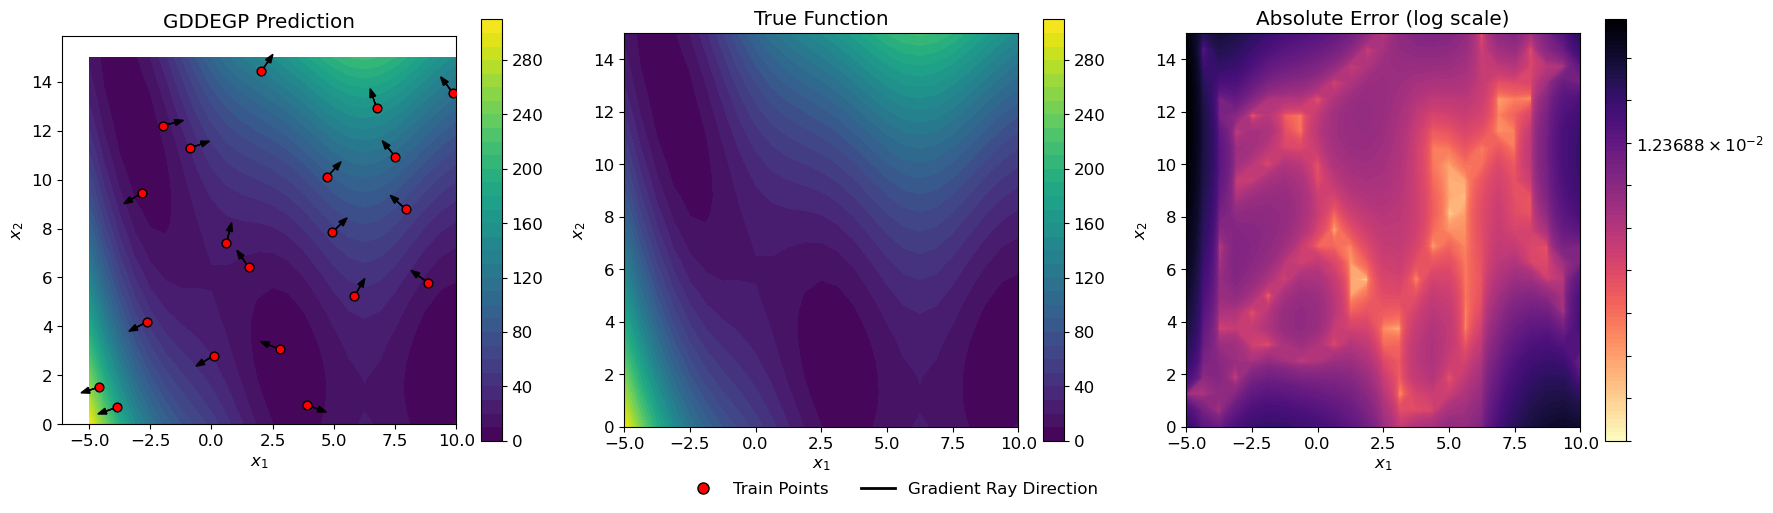


Final NRMSE: 0.000220


In [9]:
# Prepare visualization data
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# GDDEGP Prediction
cf1 = axs[0].contourf(X1_grid, X2_grid, y_pred.reshape(X1_grid.shape),
                       levels=30, cmap='viridis')
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
               edgecolors='k', zorder=5)
xlim, ylim = (domain_bounds[0], domain_bounds[1])
for pt, ray in zip(X_train, rays_list):
    clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                  bounds=(xlim, ylim), color="black")
axs[0].set_title("GDDEGP Prediction")
fig.colorbar(cf1, ax=axs[0])

# True function
cf2 = axs[1].contourf(X1_grid, X2_grid, y_true.reshape(X1_grid.shape),
                       levels=30, cmap='viridis')
axs[1].set_title("True Function")
fig.colorbar(cf2, ax=axs[1])

# Absolute Error (log scale)
abs_error = np.abs(y_pred.flatten() - y_true.flatten()).reshape(X1_grid.shape)
abs_error_clipped = np.clip(abs_error, 1e-6, None)
log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                         np.log10(abs_error_clipped.max()), num=100)
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_error_clipped, levels=log_levels,
                       norm=LogNorm(), cmap="magma_r")
fig.colorbar(cf3, ax=axs[2])
axs[2].set_title("Absolute Error (log scale)")

for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=8, label='Train Points'),
    Line2D([0], [0], color='black', lw=2, label='Gradient Ray Direction'),
]
fig.legend(handles=custom_lines, loc='lower center', ncol=2,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"\nFinal NRMSE: {nrmse_val:.6f}")

In [10]:
import numpy as np
import pyoti.sparse as oti
import itertools
from jetgp.full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import jetgp.utils as utils

plt.rcParams.update({'font.size': 12})

In [11]:
n_order = 1
n_bases = 2
num_directions_per_point = 2
num_training_pts = 10
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 25
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Directions per point: {num_directions_per_point}")
print(f"Total derivative observations: {num_training_pts * num_directions_per_point}")

Configuration complete!
Number of training points: 10
Directions per point: 2
Total derivative observations: 20


In [12]:
def true_function(X, alg=np):
    """Branin function compatible with both NumPy and pyoti arrays."""
    x, y = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1-t)*alg.cos(x) + s

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    gx = 2*a*(y - b*x**2 + c*x - r)*(-2*b*x + c) - s*(1-t)*np.sin(x)
    gy = 2*a*(y - b*x**2 + c*x - r)
    return gx, gy

print("Branin function and analytical gradient defined!")

Branin function and analytical gradient defined!


In [13]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25, head_length=0.35, fc=color, ec=color)

print("Arrow clipping utility defined!")

Arrow clipping utility defined!


In [14]:
print("Generating training data with multiple directional derivatives per point...")

import sympy as sp

# 1. Generate training points using Latin Hypercube Sampling
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples,
                    [b[0] for b in domain_bounds],
                    [b[1] for b in domain_bounds])

print(f"Generated {num_training_pts} training points using LHS")

# 2. Set up symbolic variables for gradient computation
x_sym, y_sym = sp.symbols('x y', real=True)

# Define your function symbolically (you'll need to adapt this to your actual function)
# For example, if true_function is f(x,y) = x^2 + y^2:
# f_sym = x_sym**2 + y_sym**2
x_sym, y_sym = sp.symbols('x y')
a, b, c, r, s, t = 1.0, 5.1/(4*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8*sp.pi)
f_sym = a * (y_sym - b*x_sym**2 + c*x_sym - r)**2 + s*(1 - t)*sp.cos(x_sym) + s
# Compute symbolic gradient
grad_f = [sp.diff(f_sym, x_sym), sp.diff(f_sym, y_sym)]

# Convert to numerical functions for fast evaluation
grad_x_func = sp.lambdify((x_sym, y_sym), grad_f[0], 'numpy')
grad_y_func = sp.lambdify((x_sym, y_sym), grad_f[1], 'numpy')

print(f"Created symbolic gradient functions")

# 3. Create multiple rays per point: gradient + perpendicular
rays_list = [[] for _ in range(num_directions_per_point)]
for x, y in X_train:
    # Compute gradient and its angle
    gx = grad_x_func(x, y)
    gy = grad_y_func(x, y)
    theta_grad = np.arctan2(gy, gx)
    theta_perp = theta_grad + np.pi/2

    # Create unit vectors for both directions
    ray_grad = np.array([np.cos(theta_grad), np.sin(theta_grad)]).reshape(-1, 1)
    ray_perp = np.array([np.cos(theta_perp), np.sin(theta_perp)]).reshape(-1, 1)

    rays_list[0].append(ray_grad)
    rays_list[1].append(ray_perp)

print(f"Created {num_directions_per_point} orthogonal ray directions per training point")

# 4. Compute directional derivatives using SymPy
# Directional derivative = ∇f · direction_vector
dir_deriv_sym = grad_f[0] * sp.Symbol('d_x') + grad_f[1] * sp.Symbol('d_y')

# Create lambdified function for directional derivative
dir_deriv_func = sp.lambdify((x_sym, y_sym, sp.Symbol('d_x'), sp.Symbol('d_y')),
                            dir_deriv_sym, 'numpy')

print("Computed symbolic directional derivative")

# 5. Evaluate function values and directional derivatives at all training points
y_train_list = []

# Function values
f_func = sp.lambdify((x_sym, y_sym), f_sym, 'numpy')
y_values = np.array([f_func(x, y) for x, y in X_train]).reshape(-1, 1)
y_train_list.append(y_values)

# Directional derivatives for each direction
for ray_set in rays_list:
    derivs = []
    for i, (x, y) in enumerate(X_train):
        ray = ray_set[i].flatten()
        deriv = dir_deriv_func(x, y, ray[0], ray[1])
        derivs.append(deriv)
    y_train_list.append(np.array(derivs).reshape(-1, 1))

der_indices = [[[[1, 1]], [[2, 1]]]]  # Keep for compatibility if needed

print(f"\nTraining data generated!")
print(f"  Function values: {y_train_list[0].shape}")
print(f"  Gradient direction derivatives: {y_train_list[1].shape}")
print(f"  Perpendicular direction derivatives: {y_train_list[2].shape}")

Generating training data with multiple directional derivatives per point...
Generated 10 training points using LHS
Created symbolic gradient functions
Created 2 orthogonal ray directions per training point
Computed symbolic directional derivative

Training data generated!
  Function values: (10, 1)
  Gradient direction derivatives: (10, 1)
  Perpendicular direction derivatives: (10, 1)


In [15]:
print("Initializing GDDEGP model...")

# Convert rays_list to proper format for GDDEGP
# rays_array should be shape (n_bases, num_training_pts * num_directions_per_point)
rays_array = [np.hstack(rays_list[i])
        for i in range(num_directions_per_point)]

derivative_locations = []
for i in range(len(der_indices)):
        for j in range(len(der_indices[i])):
            derivative_locations.append([i for i in range(len(X_train ))])

# Initialize GDDEGP model
gp_model = gddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    rays_list = rays_array,
    der_indices=der_indices,
    derivative_locations = derivative_locations,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("GDDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=250,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Initializing GDDEGP model...
GDDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [-0.03845983 -0.99973541  1.29794476 -6.59130785]


In [16]:
print("Evaluating model on test grid...")

# Create test grid
gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(gx, gy)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
N_test = X_test.shape[0]

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {N_test} points")

# Predict function values only
y_pred_full = gp_model.predict(
    X_test, params,
    calc_cov=False, return_deriv=False
)
y_pred = y_pred_full[0,:]

# Compute error metrics
y_true = true_function(X_test, alg=np)
nrmse = utils.nrmse(y_true.flatten(), y_pred.flatten())

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {np.max(np.abs(y_pred.flatten() - y_true.flatten())):.6f}")
print(f"  Mean absolute error: {np.mean(np.abs(y_pred.flatten() - y_true.flatten())):.6f}")

Evaluating model on test grid...
Test grid: 25×25 = 625 points

Model Performance:
  NRMSE: 0.002167
  Max absolute error: 3.974590
  Mean absolute error: 0.340369


In [17]:
print("\n" + "=" * 80)
print("Verifying interpolation of training data...")
print("=" * 80)

# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Prepare rays for prediction at training points
rays_train = [np.hstack(rays_list[i]) for i in range(num_directions_per_point)]

# Predict at training points with derivatives
y_pred_train_full = gp_model.predict(
    X_train,  params, rays_predict = rays_train, calc_cov=False, return_deriv=True
)

# Extract function values (first num_training_pts entries)
y_pred_train_func = y_pred_train_full[0,:]

print("\nFunction value interpolation errors:")
print("-" * 80)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train_func[i] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train_func - y_func_values))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("Directional derivative interpolation verification:")
print("-" * 80)
print(f"Each training point has {num_directions_per_point} directional derivatives:")
print("  Ray 1: Gradient direction")
print("  Ray 2: Perpendicular direction (orthogonal to gradient)")
print("-" * 80)


# Split into derivatives for each direction
n_derivs_per_direction = num_training_pts
pred_deriv_ray1 = y_pred_train_full[1,:]
pred_deriv_ray2 = y_pred_train_full[2,:]

# Extract analytic derivatives from training data
analytic_deriv_ray1 = y_train_list[1]  # Gradient derivatives
analytic_deriv_ray2 = y_train_list[2]  # Perpendicular derivatives

print(f"\nPrediction with derivatives shape: {y_pred_train_full.shape}")
print(f"Expected: {num_training_pts} func + {num_training_pts}×{num_directions_per_point} derivs = {num_training_pts * (1 + num_directions_per_point)}")

# Verify gradient direction derivatives (Ray 1)
print(f"\n{'='*80}")
print("RAY 1: GRADIENT DIRECTION")
print(f"{'='*80}")

for i in range(num_training_pts):
    ray_direction = rays_list[0][i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(pred_deriv_ray1[i] - analytic_deriv_ray1[i, 0])
    error_rel = error_abs / abs(analytic_deriv_ray1[i, 0]) if analytic_deriv_ray1[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_deriv_ray1[i, 0]:+.6f}, Predicted: {pred_deriv_ray1[i]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error_ray1 = np.max(np.abs(pred_deriv_ray1 - analytic_deriv_ray1))
print(f"\nMaximum absolute error for Ray 1 (gradient): {max_deriv_error_ray1:.2e}")

# Verify perpendicular direction derivatives (Ray 2)
print(f"\n{'='*80}")
print("RAY 2: PERPENDICULAR DIRECTION")
print(f"{'='*80}")

for i in range(num_training_pts):
    ray_direction = rays_list[1][i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(pred_deriv_ray2[i] - analytic_deriv_ray2[i, 0])
    error_rel = error_abs / abs(analytic_deriv_ray2[i, 0]) if analytic_deriv_ray2[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_deriv_ray2[i, 0]:+.6f}, Predicted: {pred_deriv_ray2[i]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error_ray2 = np.max(np.abs(pred_deriv_ray2 - analytic_deriv_ray2))
print(f"\nMaximum absolute error for Ray 2 (perpendicular): {max_deriv_error_ray2:.2e}")


print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: {num_directions_per_point} unique directions per training point")
print(f"  - Total constraints: {num_training_pts} function values + {num_training_pts * num_directions_per_point} directional derivatives")
print(f"  - Direction types:")
print(f"    * Ray 1: GRADIENT direction (aligned with ∇f)")
print(f"    * Ray 2: PERPENDICULAR direction (orthogonal to ∇f)")
print("=" * 80)


Verifying interpolation of training data...
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]

Function value interpolation errors:
--------------------------------------------------------------------------------
Point 0 (x=7.7323, y=10.5743): Abs Error = 2.33e-10, Rel Error = 2.45e-12
Point 1 (x=9.7838, y=7.5770): Abs Error = 7.23e-10, Rel Error = 3.03e-11
Point 2 (x=-0.9677, y=12.8650): Abs Error = 7.49e-10, Rel Error = 1.76e-11
Point 3 (x=1.2584, y=6.8862): Abs Error = 6.80e-10, Rel Error = 3.37e-11
Point 4 (x=-4.3244, y=1.4587): Abs Error = 1.97e-09, Rel Error = 9.98e-12
Point 5 (x=4.3697, y=9.6928): Abs Error = 3.79e-10, Rel Error = 5.14e-12
Point 6 (x=6.5054, y=1.8174): Abs Error = 3.75e-10, Rel Error = 1.89e-11
Point 7 (x=3.5452, y=3.8198): Abs Error = 2.61e-09, Rel Error = 5.74e-10
Point 8 (x=-2.2011, y=5.3953): Abs Error = 7.96e-10, Rel Error = 2.97e-11
Point 9 (x=0.6948, y=14.6065): Abs Error = 6.16e-09, Rel Erro

Visualizing results...


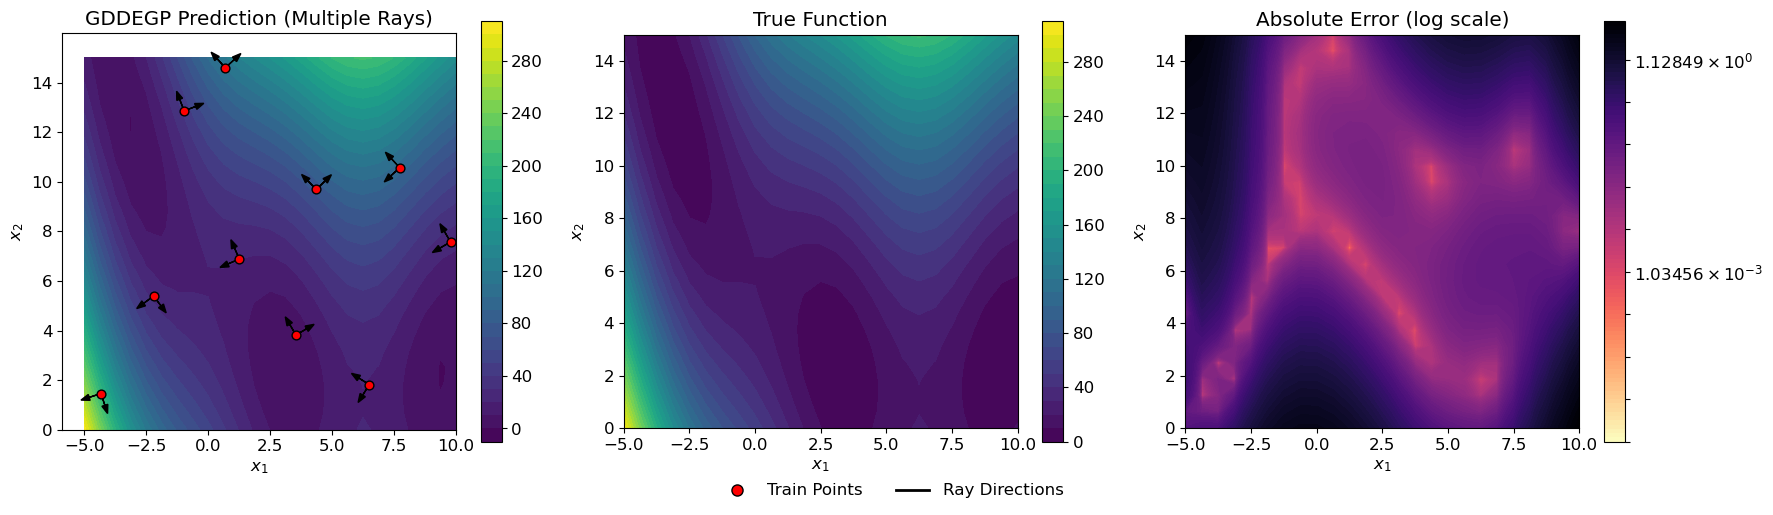


Final NRMSE: 0.002167


In [18]:
print("Visualizing results...")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# GDDEGP Prediction with multiple rays
cf1 = axs[0].contourf(X1_grid, X2_grid, y_pred.reshape(X1_grid.shape),
                      levels=30, cmap='viridis')
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
               edgecolors='k', zorder=5)
xlim, ylim = (domain_bounds[0], domain_bounds[1])

# Draw arrows for all directions
for i in range(num_directions_per_point):
    for pt, ray in zip(X_train, rays_list[i]):
        clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                     bounds=(xlim, ylim), color='black')

axs[0].set_title("GDDEGP Prediction (Multiple Rays)")
fig.colorbar(cf1, ax=axs[0])

# True function
cf2 = axs[1].contourf(X1_grid, X2_grid, y_true.reshape(X1_grid.shape),
                      levels=30, cmap='viridis')
axs[1].set_title("True Function")
fig.colorbar(cf2, ax=axs[1])

# Absolute Error (log scale)
abs_error = np.abs(y_pred.flatten() - y_true.flatten()).reshape(X1_grid.shape)
abs_error_clipped = np.clip(abs_error, 1e-6, None)
log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                        np.log10(abs_error_clipped.max()), num=100)
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_error_clipped, levels=log_levels,
                      norm=LogNorm(), cmap='magma_r')
fig.colorbar(cf3, ax=axs[2])
axs[2].set_title("Absolute Error (log scale)")

# Labels and formatting
for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=8, label='Train Points'),
    Line2D([0], [0], color='black', lw=2, label='Ray Directions'),
]
fig.legend(handles=custom_lines, loc='lower center', ncol=2,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"\nFinal NRMSE: {nrmse:.6f}")

In [19]:
import numpy as np
import sympy as sp
from jetgp.full_gddegp.gddegp import gddegp
import jetgp.utils as utils
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

In [20]:
n_order = 1
n_bases = 2
num_training_pts = 25
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 25

normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
smoothness_parameter = 3
random_seed = 42
np.random.seed(random_seed)

print("=" * 70)
print("GDDEGP Tutorial: Mixed Derivative Coverage")
print("=" * 70)
print(f"Number of training points: {num_training_pts}")
print(f"Kernel: {kernel} ({kernel_type}), smoothness={smoothness_parameter}")

GDDEGP Tutorial: Mixed Derivative Coverage
Number of training points: 25
Kernel: SE (anisotropic), smoothness=3


In [21]:
def branin_function(X, alg=np):
    """2D Branin function - a common benchmark for optimization."""
    x1, x2 = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4.0*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8.0*np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*alg.cos(x1) + s

# Define symbolic version for derivatives
x1_sym, x2_sym = sp.symbols('x1 x2')
a, b, c, r, s, t = 1.0, 5.1/(4.0*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8.0*sp.pi)
f_sym = a * (x2_sym - b*x1_sym**2 + c*x1_sym - r)**2 + s*(1 - t)*sp.cos(x1_sym) + s

# Compute gradients symbolically
grad_x1 = sp.diff(f_sym, x1_sym)
grad_x2 = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
f_func = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2, 'numpy')

print("Branin function and symbolic derivatives defined!")

Branin function and symbolic derivatives defined!


In [22]:
# Latin Hypercube Sampling for training points
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples, [b[0] for b in domain_bounds], [b[1] for b in domain_bounds])

# Compute function values at ALL points
y_func = f_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute coordinate-aligned gradients at ALL points
grad_x1_vals = grad_x1_func(X_train[:, 0], X_train[:, 1])
grad_x2_vals = grad_x2_func(X_train[:, 0], X_train[:, 1])

In [23]:
# Domain x1 range: [-5, 10], total width = 15
# Divide into regions:
#   - Boundary: 10% margin from edges (no derivatives)
#   - Left interior: x1 < 0 (Direction 1 only)
#   - Center interior: 0 <= x1 < 5 (Both directions)
#   - Right interior: x1 >= 5 (Direction 2 only)

x1_margin = 0.10 * (domain_bounds[0][1] - domain_bounds[0][0])
x2_margin = 0.10 * (domain_bounds[1][1] - domain_bounds[1][0])

# Region boundaries for x1
left_center_boundary = 0.0
center_right_boundary = 5.0

# Classify points
boundary_indices = []      # No derivatives
left_indices = []          # Direction 1 only
center_indices = []        # Both directions
right_indices = []         # Direction 2 only

for i in range(num_training_pts):
    x1, x2 = X_train[i, 0], X_train[i, 1]

    # Check if in boundary region (no derivatives)
    in_x1_interior = (domain_bounds[0][0] + x1_margin) < x1 < (domain_bounds[0][1] - x1_margin)
    in_x2_interior = (domain_bounds[1][0] + x2_margin) < x2 < (domain_bounds[1][1] - x2_margin)

    if not (in_x1_interior and in_x2_interior):
        boundary_indices.append(i)
    elif x1 < left_center_boundary:
        left_indices.append(i)
    elif x1 < center_right_boundary:
        center_indices.append(i)
    else:
        right_indices.append(i)

print(f"Point classification by region:")
print(f"  Boundary points: {len(boundary_indices)} (function values only)")
print(f"  Left region (x1 < {left_center_boundary}): {len(left_indices)} points (Direction 1 only)")
print(f"  Center region ({left_center_boundary} <= x1 < {center_right_boundary}): {len(center_indices)} points (Both directions)")
print(f"  Right region (x1 >= {center_right_boundary}): {len(right_indices)} points (Direction 2 only)")

Point classification by region:
  Boundary points: 8 (function values only)
  Left region (x1 < 0.0): 4 points (Direction 1 only)
  Center region (0.0 <= x1 < 5.0): 7 points (Both directions)
  Right region (x1 >= 5.0): 6 points (Direction 2 only)


In [24]:
# Direction 1: Left + Center regions
indices_with_dir1 = left_indices + center_indices
# Direction 2: Center + Right regions
indices_with_dir2 = center_indices + right_indices

derivative_locations = [
    indices_with_dir1,  # Points with Direction 1
    indices_with_dir2   # Points with Direction 2
]

print(f"derivative_locations structure:")
print(f"  Direction 1 at {len(indices_with_dir1)} points: {indices_with_dir1}")
print(f"  Direction 2 at {len(indices_with_dir2)} points: {indices_with_dir2}")
print(f"  Overlap (both directions): {len(center_indices)} points (center region)")

derivative_locations structure:
  Direction 1 at 11 points: [12, 16, 21, 22, 4, 5, 8, 14, 15, 17, 18]
  Direction 2 at 13 points: [4, 5, 8, 14, 15, 17, 18, 0, 2, 3, 7, 10, 11]
  Overlap (both directions): 7 points (center region)


In [25]:
# Direction 1 rays (gradient-aligned) at indices_with_dir1
rays_dir1_list = []
deriv1_values = []

for idx in indices_with_dir1:
    gx = grad_x1_vals[idx]
    gy = grad_x2_vals[idx]
    magnitude = np.sqrt(gx**2 + gy**2)

    if magnitude < 1e-10:
        ray1 = np.array([1.0, 0.0])
    else:
        ray1 = np.array([gx / magnitude, gy / magnitude])

    rays_dir1_list.append(ray1)
    dir_deriv1 = gx * ray1[0] + gy * ray1[1]
    deriv1_values.append(dir_deriv1)

# Direction 2 rays (perpendicular to gradient) at indices_with_dir2
rays_dir2_list = []
deriv2_values = []

for idx in indices_with_dir2:
    gx = grad_x1_vals[idx]
    gy = grad_x2_vals[idx]
    magnitude = np.sqrt(gx**2 + gy**2)

    if magnitude < 1e-10:
        ray2 = np.array([0.0, 1.0])
    else:
        ray2 = np.array([-gy / magnitude, gx / magnitude])

    rays_dir2_list.append(ray2)
    dir_deriv2 = gx * ray2[0] + gy * ray2[1]
    deriv2_values.append(dir_deriv2)

# Build rays_array: list of arrays, one per direction
rays_array_dir1 = np.column_stack(rays_dir1_list)  # Shape: (2, len(indices_with_dir1))
rays_array_dir2 = np.column_stack(rays_dir2_list)  # Shape: (2, len(indices_with_dir2))

rays_array = [rays_array_dir1, rays_array_dir2]

# Package derivative values
y_dir1 = np.array(deriv1_values).reshape(-1, 1)
y_dir2 = np.array(deriv2_values).reshape(-1, 1)

print(f"rays_array structure:")
print(f"  rays_array[0].shape: {rays_array[0].shape} (Direction 1 rays)")
print(f"  rays_array[1].shape: {rays_array[1].shape} (Direction 2 rays)")

rays_array structure:
  rays_array[0].shape: (2, 11) (Direction 1 rays)
  rays_array[1].shape: (2, 13) (Direction 2 rays)


In [26]:
# Package training data: [function_values, dir1_derivs, dir2_derivs]
y_train_list = [y_func, y_dir1, y_dir2]

# der_indices: two first-order directional derivatives
der_indices = [[[[1, 1]], [[2, 1]]]]

print(f"Training data summary:")
print(f"  y_train_list: {len(y_train_list)} arrays")
print(f"    - Function values: {y_func.shape} ({num_training_pts} points)")
print(f"    - Direction 1 derivatives: {y_dir1.shape} ({len(indices_with_dir1)} points)")
print(f"    - Direction 2 derivatives: {y_dir2.shape} ({len(indices_with_dir2)} points)")
print(f"  der_indices: {der_indices}")

total_constraints = y_func.shape[0] + y_dir1.shape[0] + y_dir2.shape[0]
print(f"  Total constraints: {num_training_pts} func + {len(indices_with_dir1)} dir1 + {len(indices_with_dir2)} dir2 = {total_constraints}")

Training data summary:
  y_train_list: 3 arrays
    - Function values: (25, 1) (25 points)
    - Direction 1 derivatives: (11, 1) (11 points)
    - Direction 2 derivatives: (13, 1) (13 points)
  der_indices: [[[[1, 1]], [[2, 1]]]]
  Total constraints: 25 func + 11 dir1 + 13 dir2 = 49


In [27]:
print("=" * 70)
print("Initializing GDDEGP model with mixed derivative coverage...")
print("=" * 70)

# Initialize the GDDEGP model
gp_model = gddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    der_indices=der_indices,
    derivative_locations=derivative_locations,
    rays_list=rays_array,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type,
    smoothness_parameter=smoothness_parameter
)

print("GDDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=5,
    debug=True
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Initializing GDDEGP model with mixed derivative coverage...
GDDEGP model initialized!
Optimizing hyperparameters...
New best for swarm at iteration 1: [-0.05975695 -0.89985154  0.82150297 -7.14236051] -127.01673385783165
Best after iteration 1: [-0.05975695 -0.89985154  0.82150297 -7.14236051] -127.01673385783165


New best for swarm at iteration 2: [-2.30758975e-03 -1.04043834e+00  1.81496818e+00 -1.36110435e+01] -147.52169479688217
Best after iteration 2: [-2.30758975e-03 -1.04043834e+00  1.81496818e+00 -1.36110435e+01] -147.52169479688217


New best for swarm at iteration 3: [-9.89015700e-03 -6.18065725e-01  5.48154411e-01 -1.53464673e+01] -147.9341298402955


Best after iteration 3: [-9.89015700e-03 -6.18065725e-01  5.48154411e-01 -1.53464673e+01] -147.9341298402955


New best for swarm at iteration 4: [-5.96032270e-03 -1.31590551e+00  1.62514241e+00 -1.00612742e+01] -161.4272571974413


...

New best for swarm at iteration 10: [ -0.06055641  -1.06478688   1.47535944 -13.33686537] -202.9466747655565
Gradient refinement improved
Best after iteration 10: [ -0.06080837  -1.06490837   1.47503787 -13.33686537] -203.6011210472446


New best for swarm at iteration 11: [ -0.0853344   -1.05942049   1.52923873 -12.64275511] -203.81616990170295


New best for swarm at iteration 11: [ -0.06276941  -1.05081869   1.35481998 -13.0759044 ] -204.74914926543636
Best after iteration 11: [ -0.06276941  -1.05081869   1.35481998 -13.0759044 ] -204.74914926543636
New best for swarm at iteration 12: [ -0.06282024  -1.07209807   1.36687453 -12.93736564] -205.10064528183676
New best for swarm at iteration 12: [ -0.06542885  -1.04703914   1.39701843 -12.42923892] -205.17862144976795
Best after iteration 12: [ -0.06542885  -1.04703914   1.39701843 -12.42923892] -205.17862144976795
New best for swarm at iteration 13: [ -0.06781423  -1.05602187   1.40202334 -13.78588706] -205.4138356319786
New best for swarm at iteration 13: [ -0.07339875  -1.05016206   1.43183376 -12.73347808] -205.97638624164927
Best after iteration 13: [ -0.07339875  -1.05016206   1.43183376 -12.73347808] -205.97638624164927


New best for swarm at iteration 14: [ -0.07314984  -1.05953129   1.42097946 -13.35282028] -206.86342389941234
Best after iteration 14: [ -0.07314984  -1.05953129   1.42097946 -13.35282028] -206.86342389941234


New best for swarm at iteration 15: [ -0.06923866  -1.11549155   1.4803229  -12.8926895 ] -207.3349316536997
Local optimization did not improve:
Best after iteration 15: [ -0.06923866  -1.11549155   1.4803229  -12.8926895 ] -207.3349316536997
Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [ -0.06923866  -1.11549155   1.4803229  -12.8926895 ]


In [28]:
print("=" * 70)
print("Evaluating model on test grid...")
print("=" * 70)

# Create dense test grid
x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {len(X_test)} points")

# Predict function values only
y_pred_full = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)
y_pred = y_pred_full[0, :]

# Compute ground truth and error
y_true = branin_function(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

# Regional error analysis
left_mask = X_test[:, 0] < left_center_boundary
center_mask = (X_test[:, 0] >= left_center_boundary) & (X_test[:, 0] < center_right_boundary)
right_mask = X_test[:, 0] >= center_right_boundary

print(f"\nRegional NRMSE:")
print(f"  Left region (Dir 1 only):   {utils.nrmse(y_true[left_mask], y_pred[left_mask]):.6f}")
print(f"  Center region (Both dirs):  {utils.nrmse(y_true[center_mask], y_pred[center_mask]):.6f}")
print(f"  Right region (Dir 2 only):  {utils.nrmse(y_true[right_mask], y_pred[right_mask]):.6f}")

Evaluating model on test grid...
Test grid: 25×25 = 625 points



Model Performance:
  NRMSE: 0.000073
  Max absolute error: 0.127968
  Mean absolute error: 0.008617

Regional NRMSE:
  Left region (Dir 1 only):   0.000091
  Center region (Both dirs):  0.000005
  Right region (Dir 2 only):  0.000124


In [29]:
print("=" * 70)
print("Verifying interpolation at training points...")
print("=" * 70)

# Predict function values at ALL training points
y_pred_train_func = gp_model.predict(
    X_train, params, calc_cov=False, return_deriv=False
)

pred_func = y_pred_train_func[0, :]
func_errors = np.abs(pred_func - y_func.flatten())
print(f"\nFunction value interpolation (all {num_training_pts} points):")
print(f"  Max error: {func_errors.max():.2e}")
print(f"  Mean error: {func_errors.mean():.2e}")

Verifying interpolation at training points...

Function value interpolation (all 25 points):
  Max error: 5.38e-05
  Mean error: 2.04e-05


In [30]:
print(f"\n--- Verifying Direction 1 derivatives ---")
print(f"Direction 1 exists at {len(indices_with_dir1)} points: {indices_with_dir1}")

# Get the points that have Direction 1
X_dir1_points = X_train[indices_with_dir1]

# For prediction, we need rays that match these test points
# rays_array_dir1 already has the correct correspondence
y_pred_dir1 = gp_model.predict(
     X_dir1_points, params,
     rays_predict=[rays_array_dir1, rays_array_dir2[:, 0:rays_array_dir1.shape[1]]],
     calc_cov=False,
     return_deriv=True
 )

print(f"Prediction shape: {y_pred_dir1.shape}")
print(f"Expected: [2 rows, {len(indices_with_dir1)} columns]")

pred_dir1 = y_pred_dir1[1, :]
dir1_errors = np.abs(pred_dir1 - y_dir1.flatten())
print(f"\nDirection 1 interpolation:")
print(f"  Max error: {dir1_errors.max():.2e}")
print(f"  Mean error: {dir1_errors.mean():.2e}")


--- Verifying Direction 1 derivatives ---
Direction 1 exists at 11 points: [12, 16, 21, 22, 4, 5, 8, 14, 15, 17, 18]
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
Prediction shape: (3, 11)
Expected: [2 rows, 11 columns]

Direction 1 interpolation:
  Max error: 5.20e-06
  Mean error: 2.44e-06


In [31]:
print(f"\n--- Verifying Direction 2 derivatives ---")
print(f"Direction 2 exists at {len(indices_with_dir2)} points: {indices_with_dir2}")

# Get the points that have Direction 2
X_dir2_points = X_train[indices_with_dir2]

y_pred_dir2 = gp_model.predict(
    X_dir2_points, params,
    rays_predict=[rays_array_dir2, rays_array_dir2],
    calc_cov=False,
    return_deriv=True
)

print(f"Prediction shape: {y_pred_dir2.shape}")
print(f"Expected: [2 rows, {len(indices_with_dir2)} columns]")

pred_dir2 = y_pred_dir2[1, :]
dir2_errors = np.abs(pred_dir2 - y_dir2.flatten())
print(f"\nDirection 2 interpolation:")
print(f"  Max error: {dir2_errors.max():.2e}")
print(f"  Mean error: {dir2_errors.mean():.2e}")


--- Verifying Direction 2 derivatives ---
Direction 2 exists at 13 points: [4, 5, 8, 14, 15, 17, 18, 0, 2, 3, 7, 10, 11]
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
Prediction shape: (3, 13)
Expected: [2 rows, 13 columns]

Direction 2 interpolation:
  Max error: 5.37e-06
  Mean error: 1.67e-06


In [32]:
print(f"\n--- Verifying BOTH directions at center points ---")
print(f"Center region has {len(center_indices)} points with both directions: {center_indices}")

if len(center_indices) > 0:
    X_center_points = X_train[center_indices]

    # Build rays for center points (both directions)
    # Need to find which indices in rays_array_dir1 and rays_array_dir2 correspond to center points

    # For dir1: center_indices are at positions [len(left_indices):] in indices_with_dir1
    center_pos_in_dir1 = list(range(len(left_indices), len(indices_with_dir1)))
    rays_center_dir1 = rays_array_dir1[:, center_pos_in_dir1]

    # For dir2: center_indices are at positions [:len(center_indices)] in indices_with_dir2
    center_pos_in_dir2 = list(range(len(center_indices)))
    rays_center_dir2 = rays_array_dir2[:, center_pos_in_dir2]

    print(f"  rays_center_dir1.shape: {rays_center_dir1.shape}")
    print(f"  rays_center_dir2.shape: {rays_center_dir2.shape}")

    y_pred_center = gp_model.predict(
        X_center_points, params,
        rays_predict=[rays_center_dir1, rays_center_dir2],
        calc_cov=False,
        return_deriv=True
    )

    print(f"Prediction shape: {y_pred_center.shape}")
    print(f"Expected: [3 rows, {len(center_indices)} columns]")

    # Get true values for center points
    # Dir1 values for center: positions [len(left_indices):] in y_dir1
    true_dir1_center = y_dir1.flatten()[center_pos_in_dir1]
    # Dir2 values for center: positions [:len(center_indices)] in y_dir2
    true_dir2_center = y_dir2.flatten()[center_pos_in_dir2]

    pred_center_dir1 = y_pred_center[1, :]
    pred_center_dir2 = y_pred_center[2, :]

    center_dir1_errors = np.abs(pred_center_dir1 - true_dir1_center)
    center_dir2_errors = np.abs(pred_center_dir2 - true_dir2_center)

    print(f"\nCenter region - Direction 1:")
    print(f"  Max error: {center_dir1_errors.max():.2e}")
    print(f"  Mean error: {center_dir1_errors.mean():.2e}")

    print(f"\nCenter region - Direction 2:")
    print(f"  Max error: {center_dir2_errors.max():.2e}")
    print(f"  Mean error: {center_dir2_errors.mean():.2e}")


--- Verifying BOTH directions at center points ---
Center region has 7 points with both directions: [4, 5, 8, 14, 15, 17, 18]
  rays_center_dir1.shape: (2, 7)
  rays_center_dir2.shape: (2, 7)
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
Prediction shape: (3, 7)
Expected: [3 rows, 7 columns]

Center region - Direction 1:
  Max error: 5.20e-06
  Mean error: 2.36e-06

Center region - Direction 2:
  Max error: 2.23e-06
  Mean error: 1.16e-06


Creating visualization...


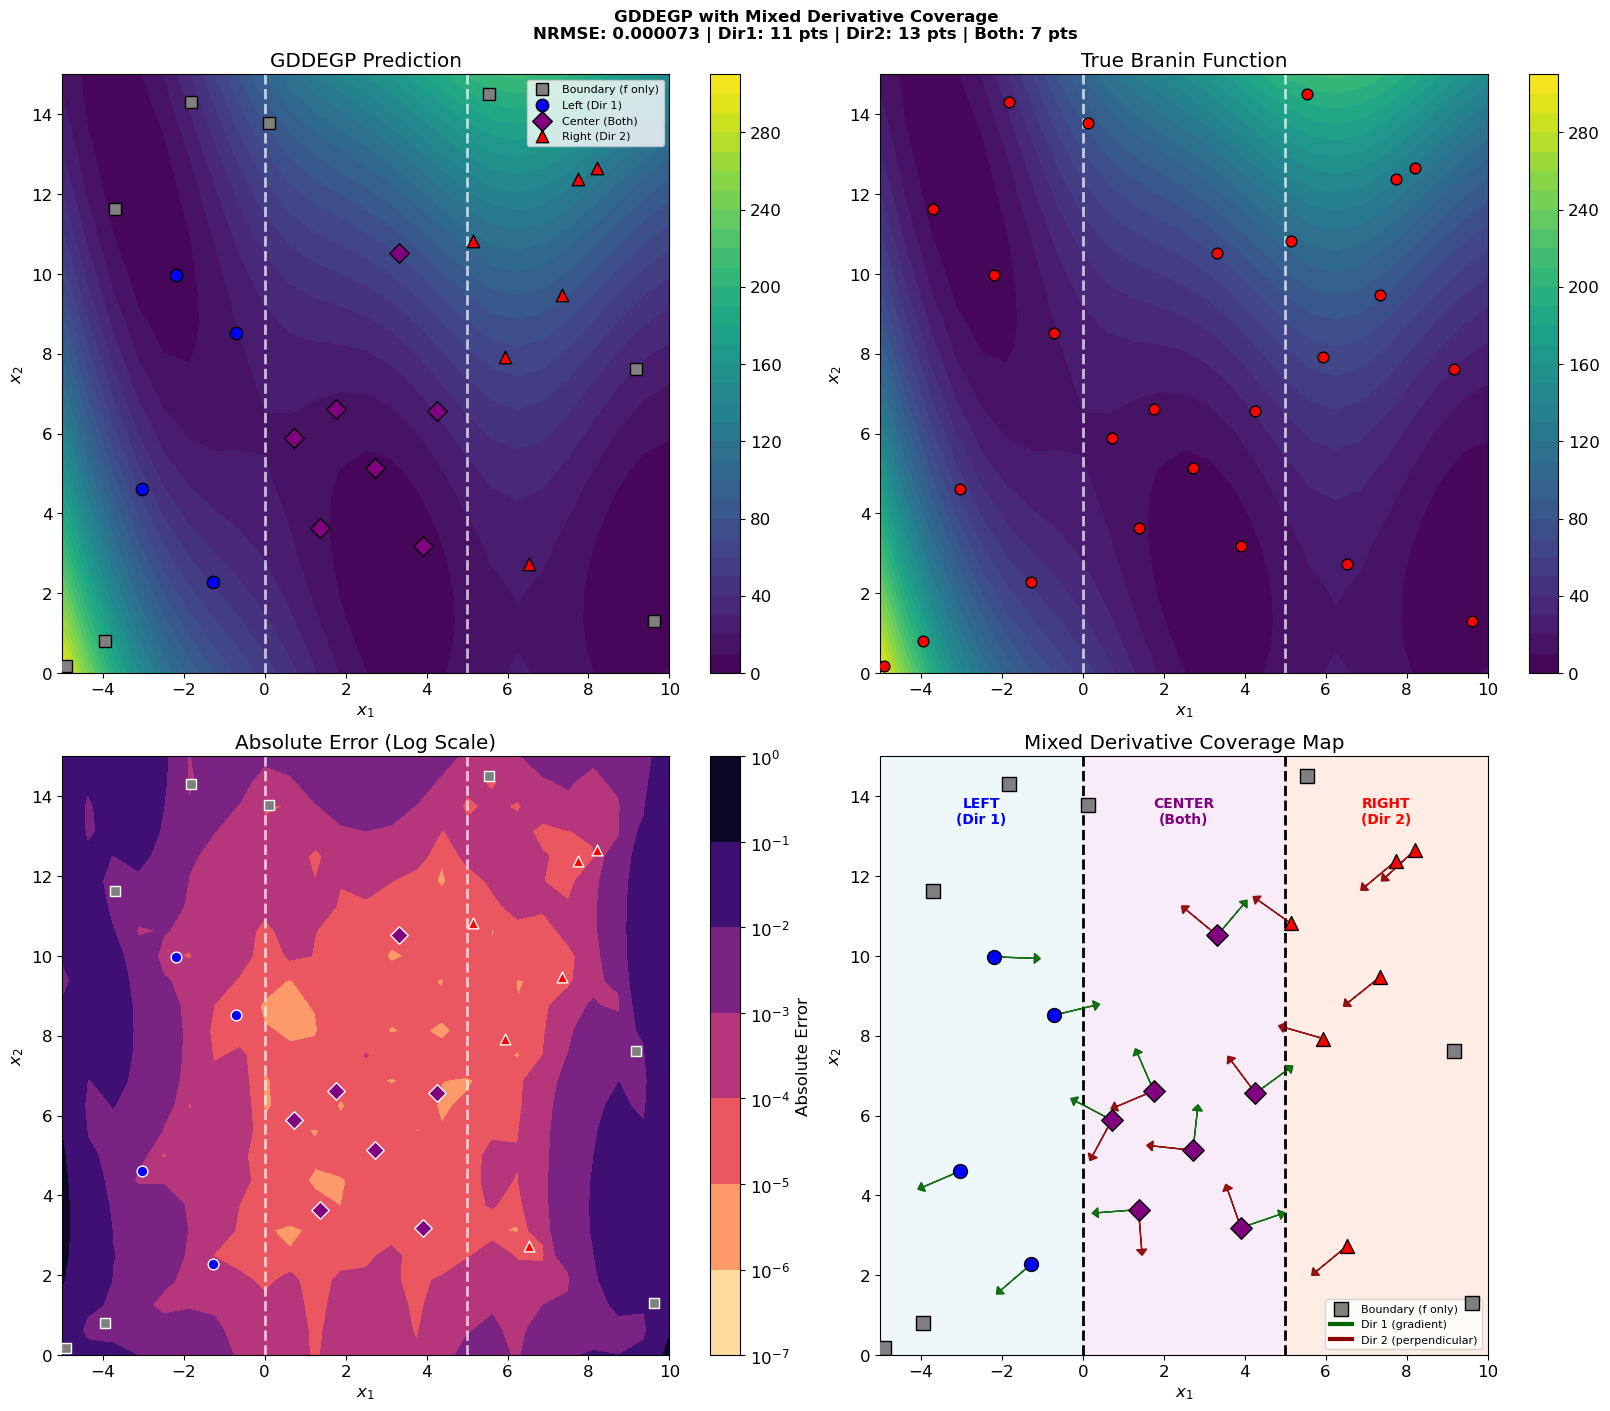

In [33]:
print("=" * 70)
print("Creating visualization...")
print("=" * 70)

# Prepare visualization data
gp_map = y_pred.reshape(X1_grid.shape)
true_map = y_true.reshape(X1_grid.shape)
abs_err = np.abs(gp_map - true_map)
abs_err_clipped = np.clip(abs_err, 1e-8, None)

# Create four-panel figure
fig, axs = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

# Panel 1: GP Prediction with region boundaries
ax = axs[0, 0]
cf1 = ax.contourf(X1_grid, X2_grid, gp_map, cmap='viridis', levels=30)
fig.colorbar(cf1, ax=ax)

# Draw region boundaries
ax.axvline(x=left_center_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=center_right_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)

# Plot points by category
ax.scatter(X_train[boundary_indices, 0], X_train[boundary_indices, 1],
           c='gray', s=80, edgecolors='black', zorder=5, marker='s', label='Boundary (f only)')
ax.scatter(X_train[left_indices, 0], X_train[left_indices, 1],
           c='blue', s=80, edgecolors='black', zorder=5, marker='o', label='Left (Dir 1)')
ax.scatter(X_train[center_indices, 0], X_train[center_indices, 1],
           c='purple', s=100, edgecolors='black', zorder=5, marker='D', label='Center (Both)')
ax.scatter(X_train[right_indices, 0], X_train[right_indices, 1],
           c='red', s=80, edgecolors='black', zorder=5, marker='^', label='Right (Dir 2)')

ax.set_title("GDDEGP Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc='upper right', fontsize=8)

# Panel 2: True Function
ax = axs[0, 1]
cf2 = ax.contourf(X1_grid, X2_grid, true_map, cmap='viridis', levels=30)
fig.colorbar(cf2, ax=ax)
ax.axvline(x=left_center_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=center_right_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter(X_train[:, 0], X_train[:, 1], c='red', s=60, edgecolors='black', zorder=5)
ax.set_title("True Branin Function")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Panel 3: Absolute Error
ax = axs[1, 0]
cf3 = ax.contourf(X1_grid, X2_grid, abs_err_clipped, norm=LogNorm(), cmap='magma_r', levels=30)
fig.colorbar(cf3, ax=ax, label='Absolute Error')
ax.axvline(x=left_center_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=center_right_boundary, color='white', linestyle='--', linewidth=2, alpha=0.7)

ax.scatter(X_train[boundary_indices, 0], X_train[boundary_indices, 1],
           c='gray', s=60, edgecolors='white', zorder=5, marker='s')
ax.scatter(X_train[left_indices, 0], X_train[left_indices, 1],
           c='blue', s=60, edgecolors='white', zorder=5, marker='o')
ax.scatter(X_train[center_indices, 0], X_train[center_indices, 1],
           c='purple', s=80, edgecolors='white', zorder=5, marker='D')
ax.scatter(X_train[right_indices, 0], X_train[right_indices, 1],
           c='red', s=60, edgecolors='white', zorder=5, marker='^')

ax.set_title("Absolute Error (Log Scale)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Panel 4: Mixed Ray Coverage Map
ax = axs[1, 1]
ax.set_xlim(domain_bounds[0])
ax.set_ylim(domain_bounds[1])

# Draw region shading
rect_left = plt.Rectangle((domain_bounds[0][0], domain_bounds[1][0]),
                           left_center_boundary - domain_bounds[0][0],
                           domain_bounds[1][1] - domain_bounds[1][0],
                           fill=True, facecolor='lightblue', alpha=0.2)
ax.add_patch(rect_left)

rect_center = plt.Rectangle((left_center_boundary, domain_bounds[1][0]),
                             center_right_boundary - left_center_boundary,
                             domain_bounds[1][1] - domain_bounds[1][0],
                             fill=True, facecolor='plum', alpha=0.2)
ax.add_patch(rect_center)

rect_right = plt.Rectangle((center_right_boundary, domain_bounds[1][0]),
                            domain_bounds[0][1] - center_right_boundary,
                            domain_bounds[1][1] - domain_bounds[1][0],
                            fill=True, facecolor='lightsalmon', alpha=0.2)
ax.add_patch(rect_right)

# Draw region boundaries
ax.axvline(x=left_center_boundary, color='black', linestyle='--', linewidth=2)
ax.axvline(x=center_right_boundary, color='black', linestyle='--', linewidth=2)

# Plot boundary points
ax.scatter(X_train[boundary_indices, 0], X_train[boundary_indices, 1],
           c='gray', s=100, edgecolors='black', zorder=10, marker='s', label='Boundary (f only)')

# Draw rays for each region
ray_length = 1.0

# Left region: Direction 1 only (green arrows)
for i, idx in enumerate(left_indices):
    pt = X_train[idx]
    pos_in_dir1 = i
    ray = rays_array_dir1[:, pos_in_dir1]
    ax.scatter(pt[0], pt[1], c='blue', s=100, edgecolors='black', zorder=10, marker='o')
    ax.arrow(pt[0], pt[1], ray[0]*ray_length, ray[1]*ray_length,
             head_width=0.25, head_length=0.15, fc='darkgreen', ec='darkgreen', alpha=0.9, zorder=5)

# Center region: Both directions
for i, idx in enumerate(center_indices):
    pt = X_train[idx]
    ax.scatter(pt[0], pt[1], c='purple', s=120, edgecolors='black', zorder=10, marker='D')

    pos_in_dir1 = len(left_indices) + i
    ray1 = rays_array_dir1[:, pos_in_dir1]
    ax.arrow(pt[0], pt[1], ray1[0]*ray_length, ray1[1]*ray_length,
             head_width=0.25, head_length=0.15, fc='darkgreen', ec='darkgreen', alpha=0.9, zorder=5)

    pos_in_dir2 = i
    ray2 = rays_array_dir2[:, pos_in_dir2]
    ax.arrow(pt[0], pt[1], ray2[0]*ray_length, ray2[1]*ray_length,
             head_width=0.25, head_length=0.15, fc='darkred', ec='darkred', alpha=0.9, zorder=5)

# Right region: Direction 2 only (red arrows)
for i, idx in enumerate(right_indices):
    pt = X_train[idx]
    pos_in_dir2 = len(center_indices) + i
    ray = rays_array_dir2[:, pos_in_dir2]
    ax.scatter(pt[0], pt[1], c='red', s=100, edgecolors='black', zorder=10, marker='^')
    ax.arrow(pt[0], pt[1], ray[0]*ray_length, ray[1]*ray_length,
             head_width=0.25, head_length=0.15, fc='darkred', ec='darkred', alpha=0.9, zorder=5)

ax.plot([], [], color='darkgreen', linewidth=3, label='Dir 1 (gradient)')
ax.plot([], [], color='darkred', linewidth=3, label='Dir 2 (perpendicular)')

ax.text(-2.5, 14, 'LEFT\n(Dir 1)', ha='center', va='top', fontsize=10, fontweight='bold', color='blue')
ax.text(2.5, 14, 'CENTER\n(Both)', ha='center', va='top', fontsize=10, fontweight='bold', color='purple')
ax.text(7.5, 14, 'RIGHT\n(Dir 2)', ha='center', va='top', fontsize=10, fontweight='bold', color='red')

ax.set_title("Mixed Derivative Coverage Map")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc='lower right', fontsize=8)

plt.suptitle(f"GDDEGP with Mixed Derivative Coverage\n"
             f"NRMSE: {nrmse:.6f} | Dir1: {len(indices_with_dir1)} pts | Dir2: {len(indices_with_dir2)} pts | "
             f"Both: {len(center_indices)} pts",
             fontsize=12, fontweight='bold')

plt.savefig("gddegp_mixed_coverage.png", dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Training configuration:")
print(f"  - {num_training_pts} total training points")
print(f"  - {len(boundary_indices)} boundary points (function only)")
print(f"  - {len(left_indices)} left region points (Direction 1 only)")
print(f"  - {len(center_indices)} center region points (Both directions)")
print(f"  - {len(right_indices)} right region points (Direction 2 only)")

print(f"\nKey data structures:")
print(f"  derivative_locations = [")
print(f"      {indices_with_dir1},  # Direction 1 (left + center)")
print(f"      {indices_with_dir2}   # Direction 2 (center + right)")
print(f"  ]")
print(f"  rays_array = [")
print(f"      array of shape {rays_array[0].shape},  # Direction 1 rays")
print(f"      array of shape {rays_array[1].shape}   # Direction 2 rays")
print(f"  ]")

print(f"\nCoverage summary:")
print(f"  - Direction 1 at {len(indices_with_dir1)} points")
print(f"  - Direction 2 at {len(indices_with_dir2)} points")
print(f"  - Overlap (both): {len(center_indices)} points")
print(f"  - Total derivative constraints: {len(indices_with_dir1) + len(indices_with_dir2)}")

print(f"\nModel performance:")
print(f"  - Overall NRMSE: {nrmse:.6f}")
print(f"  - Function max interpolation error: {func_errors.max():.2e}")
print(f"  - Dir 1 max interpolation error: {dir1_errors.max():.2e}")
print(f"  - Dir 2 max interpolation error: {dir2_errors.max():.2e}")
print("=" * 70)
print("Figure saved to gddegp_mixed_coverage.png")

SUMMARY
Training configuration:
  - 25 total training points
  - 8 boundary points (function only)
  - 4 left region points (Direction 1 only)
  - 7 center region points (Both directions)
  - 6 right region points (Direction 2 only)

Key data structures:
  derivative_locations = [
      [12, 16, 21, 22, 4, 5, 8, 14, 15, 17, 18],  # Direction 1 (left + center)
      [4, 5, 8, 14, 15, 17, 18, 0, 2, 3, 7, 10, 11]   # Direction 2 (center + right)
  ]
  rays_array = [
      array of shape (2, 11),  # Direction 1 rays
      array of shape (2, 13)   # Direction 2 rays
  ]

Coverage summary:
  - Direction 1 at 11 points
  - Direction 2 at 13 points
  - Overlap (both): 7 points
  - Total derivative constraints: 24

Model performance:
  - Overall NRMSE: 0.000073
  - Function max interpolation error: 5.38e-05
  - Dir 1 max interpolation error: 5.20e-06
  - Dir 2 max interpolation error: 5.37e-06
Figure saved to gddegp_mixed_coverage.png


In [35]:
import numpy as np
from jetgp.full_gddegp.gddegp import gddegp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

Modules imported successfully.


In [36]:
np.random.seed(42)

# 2D input space — 5×5 grid
x_vals = np.linspace(0, 1, 5)
X_train = np.array([[x1, x2] for x1 in x_vals for x2 in x_vals])
n_train = len(X_train)

def f(X):      return np.sin(X[:, 0]) + X[:, 1] ** 2
def df_dx1(X): return np.cos(X[:, 0])
def df_dx2(X): return 2.0 * X[:, 1]
def dir_deriv(X, ray):
    g = np.stack([df_dx1(X), df_dx2(X)], axis=1)  # (n, 2)
    return (g @ ray).flatten()

# Three fixed direction types for all training points
ray_x1   = np.array([1.0, 0.0])            # x1-axis
ray_x2   = np.array([0.0, 1.0])            # x2-axis
ray_diag = np.array([np.cos(np.pi/4),
                     np.sin(np.pi/4)])     # 45° diagonal

print(f"Training points     : {n_train}  (5×5 grid)")
print(f"Spatial dimension   : 2")
print(f"Direction types     : 3  →  n_bases = 2×3 = 6 (OTI pairs e1-e2, e3-e4, e5-e6)")
print(f"Old (broken) formula: n_bases = 2×spatial_dim = 2×2 = 4  (too small!)")

Training points     : 25  (5×5 grid)
Spatial dimension   : 2
Direction types     : 3  →  n_bases = 2×3 = 6 (OTI pairs e1-e2, e3-e4, e5-e6)
Old (broken) formula: n_bases = 2×spatial_dim = 2×2 = 4  (too small!)


In [37]:
y_func = f(X_train).reshape(-1, 1)

# Directional derivative values at each training point for each direction type
y_dir1 = dir_deriv(X_train, ray_x1).reshape(-1, 1)    # df along x1-axis
y_dir2 = dir_deriv(X_train, ray_x2).reshape(-1, 1)    # df along x2-axis
y_dir3 = dir_deriv(X_train, ray_diag).reshape(-1, 1)  # df along 45°

y_train = [y_func, y_dir1, y_dir2, y_dir3]

# rays_list[k] has shape (spatial_dim, n_points_with_direction_k)
# Here every training point has every direction, so shape is (2, n_train) each.
rays_list = [
    np.tile(ray_x1.reshape(-1, 1),   (1, n_train)),   # direction type 1
    np.tile(ray_x2.reshape(-1, 1),   (1, n_train)),   # direction type 2
    np.tile(ray_diag.reshape(-1, 1), (1, n_train)),   # direction type 3
]

# Three direction types: OTI indices [1,1], [2,1], [3,1]
der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]
derivative_locations = [list(range(n_train))] * 3

print("y_train shapes    :", [v.shape for v in y_train])
print("rays_list shapes  :", [r.shape for r in rays_list])
print("der_indices       :", der_indices)

y_train shapes    : [(25, 1), (25, 1), (25, 1), (25, 1)]
rays_list shapes  : [(2, 25), (2, 25), (2, 25)]
der_indices       : [[[[1, 1]], [[2, 1]], [[3, 1]]]]


In [38]:
# GDDEGP automatically sets n_bases = 2 * len(flattened_der_indices) = 2*3 = 6
model = gddegp(
    X_train, y_train,
    n_order=1,
    rays_list=rays_list,
    der_indices=der_indices,
    derivative_locations=derivative_locations,
    normalize=True,
    kernel="SE", kernel_type="anisotropic"
)

print(f"n_bases (OTI space size) : {model.n_bases}")
print(f"  = 2 × n_direction_types = 2 × 3 = 6  ✓")
print(f"  (old formula would have given 2 × spatial_dim = 2 × 2 = 4  ✗)")

n_bases (OTI space size) : 6
  = 2 × n_direction_types = 2 × 3 = 6  ✓
  (old formula would have given 2 × spatial_dim = 2 × 2 = 4  ✗)


In [39]:
params = model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=100,
    n_generations=30,
    local_opt_every=30,
    debug=False
)
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 30
Optimized hyperparameters: [-0.8988436  -0.5990696   0.54890597 -7.02446261]


In [40]:
np.random.seed(7)
X_test = np.random.uniform(0, 1, (40, 2))
n_test = len(X_test)

# Provide rays at test points for all 3 direction types
rays_predict = [
    np.tile(ray_x1.reshape(-1, 1),   (1, n_test)),
    np.tile(ray_x2.reshape(-1, 1),   (1, n_test)),
    np.tile(ray_diag.reshape(-1, 1), (1, n_test)),
]

pred = model.predict(
    X_test, params,
    rays_predict=rays_predict,
    calc_cov=False,
    return_deriv=True,
    derivs_to_predict=[[[1, 1]], [[2, 1]], [[3, 1]]]
)

# pred shape: (4, n_test) — row 0 = f, rows 1–3 = directional derivatives
f_pred    = pred[0, :]
dir1_pred = pred[1, :]
dir2_pred = pred[2, :]
dir3_pred = pred[3, :]

f_true    = f(X_test).flatten()
dir1_true = dir_deriv(X_test, ray_x1)
dir2_true = dir_deriv(X_test, ray_x2)
dir3_true = dir_deriv(X_test, ray_diag)

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def corr(a, b): return float(np.corrcoef(a, b)[0, 1])

print(f"{'Quantity':<25} {'RMSE':>10}  {'Correlation':>12}")
print("-" * 52)
print(f"{'f(x)':<25} {rmse(f_pred, f_true):>10.4e}  {corr(f_pred, f_true):>12.4f}")
print(f"{'df/dr1 (x1-axis)':<25} {rmse(dir1_pred, dir1_true):>10.4e}  {corr(dir1_pred, dir1_true):>12.4f}")
print(f"{'df/dr2 (x2-axis)':<25} {rmse(dir2_pred, dir2_true):>10.4e}  {corr(dir2_pred, dir2_true):>12.4f}")
print(f"{'df/dr3 (45° diag)':<25} {rmse(dir3_pred, dir3_true):>10.4e}  {corr(dir3_pred, dir3_true):>12.4f}")

Quantity                        RMSE   Correlation
----------------------------------------------------
f(x)                      3.5038e-08        1.0000
df/dr1 (x1-axis)          5.1686e-08        1.0000
df/dr2 (x2-axis)          8.1851e-08        1.0000
df/dr3 (45° diag)         6.7183e-08        1.0000


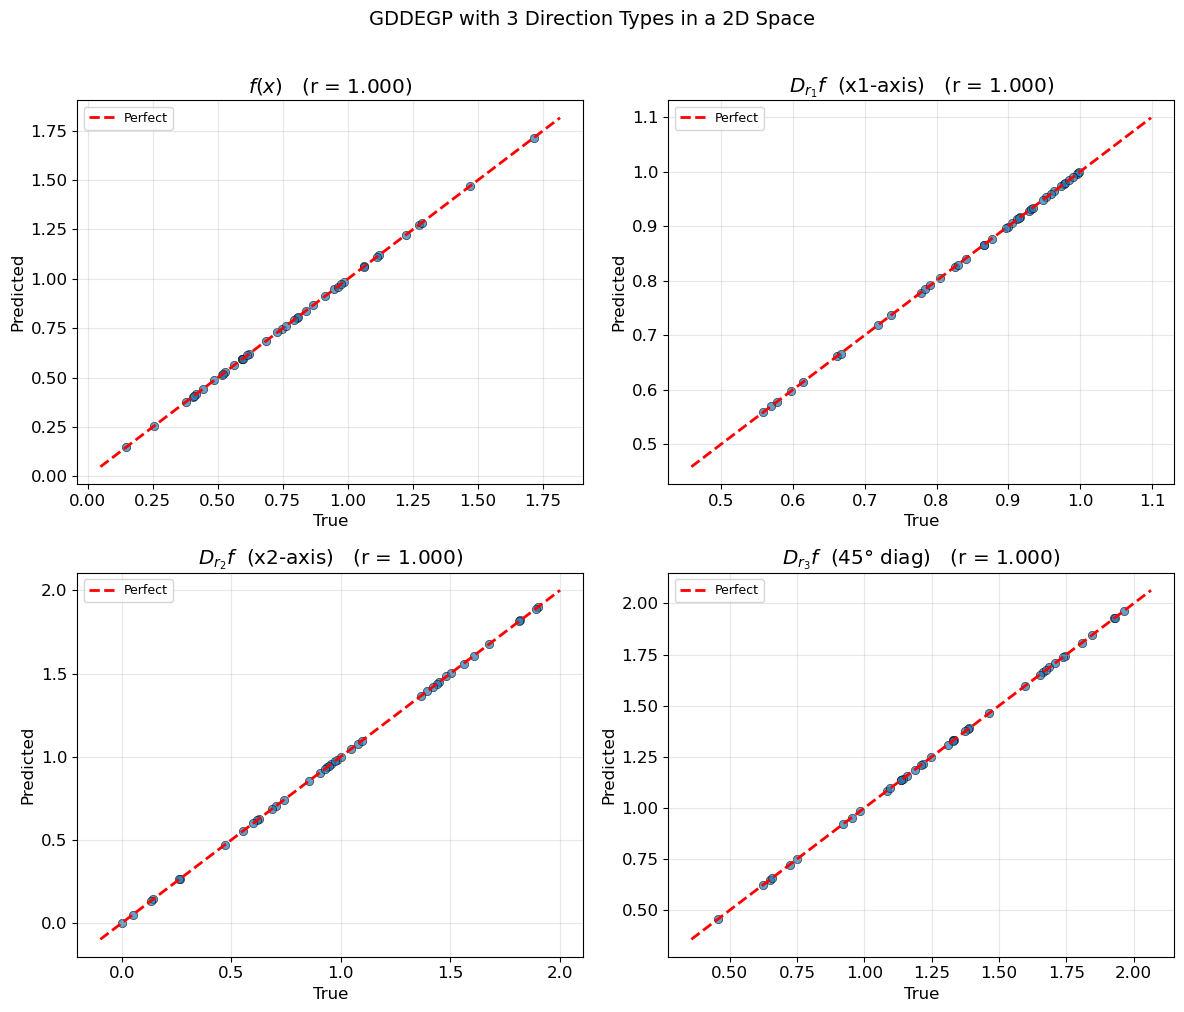

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [
    (f_pred,    f_true,    r'$f(x)$'),
    (dir1_pred, dir1_true, r'$D_{r_1} f$  (x1-axis)'),
    (dir2_pred, dir2_true, r'$D_{r_2} f$  (x2-axis)'),
    (dir3_pred, dir3_true, r'$D_{r_3} f$  (45° diag)'),
]

for ax, (pred_vals, true_vals, label) in zip(axes.flat, pairs):
    ax.scatter(true_vals, pred_vals, alpha=0.7, edgecolors='k', linewidths=0.5)
    lo = min(true_vals.min(), pred_vals.min()) - 0.1
    hi = max(true_vals.max(), pred_vals.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect')
    r = corr(pred_vals, true_vals)
    ax.set_title(f'{label}   (r = {r:.3f})')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('GDDEGP with 3 Direction Types in a 2D Space', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [42]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from jetgp.full_gddegp.gddegp import gddegp

print("Modules imported successfully.")

Modules imported successfully.


In [43]:
def f(X):
    return np.sin(X[:, 0]) * np.cos(X[:, 1])

def df_dx1(X):
    return np.cos(X[:, 0]) * np.cos(X[:, 1])

def df_dx2(X):
    return -np.sin(X[:, 0]) * np.sin(X[:, 1])

# 5×5 training grid — function values ONLY
x1_tr = np.linspace(0, 2 * np.pi, 6)
x2_tr = np.linspace(0, 2 * np.pi, 6)
G1, G2 = np.meshgrid(x1_tr, x2_tr)
X_train = np.column_stack([G1.ravel(), G2.ravel()])  # shape (36, 2)
y_func  = f(X_train).reshape(-1, 1)
y_train = [y_func]  # no derivative arrays

print(f"X_train shape : {X_train.shape}")

X_train shape : (36, 2)


In [44]:
# n_bases must be set explicitly when der_indices=[] because there are no
# training derivative types from which to auto-infer the OTI space size.
# We plan to predict 2 directional derivatives → n_bases = 2 * 2 = 4.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = gddegp(
        X_train, y_train,
        n_order=1,
        rays_list=[],
        der_indices=[],
        derivative_locations=[],
        n_bases=4,
        normalize=True,
        kernel="SE", kernel_type="anisotropic",
    )

print("GDDEGP model (function-only, 2D) initialised.")

GDDEGP model (function-only, 2D) initialised.


In [45]:
params = model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=100,
    n_generations=15,
    local_opt_every=15,
    debug=False,
)
print("Optimised hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimised hyperparameters: [-1.39083569e-02  4.47278616e-02  4.47652758e-01 -1.51974132e+01]


In [46]:
n_test = 20
x1_te = np.linspace(0, 2 * np.pi, n_test)
x2_te = np.linspace(0, 2 * np.pi, n_test)
G1t, G2t = np.meshgrid(x1_te, x2_te)
X_test = np.column_stack([G1t.ravel(), G2t.ravel()])
N_test = X_test.shape[0]

# rays_predict[dir_idx] has shape (d, n_test).
# Each column is the unit direction vector at that test point.
# Direction 0: [1, 0]  →  x1-axis (gives df/dx1)
# Direction 1: [0, 1]  →  x2-axis (gives df/dx2)
rays_predict = [
    np.tile(np.array([[1.0], [0.0]]), (1, N_test)),
    np.tile(np.array([[0.0], [1.0]]), (1, N_test)),
]

# derivs_to_predict: [[1,1]] → 1st-order w.r.t. OTI pair 1 (direction 0)
#                    [[2,1]] → 1st-order w.r.t. OTI pair 2 (direction 1)
mean, var = model.predict(
    X_test, params,
    rays_predict=rays_predict,
    calc_cov=True,
    return_deriv=True,
    derivs_to_predict=[[[1, 1]], [[2, 1]]],
)

shape2d = (n_test, n_test)
f_mean_grid   = mean[0, :].reshape(shape2d)
dx1_mean_grid = mean[1, :].reshape(shape2d)
dx2_mean_grid = mean[2, :].reshape(shape2d)

f_true_grid   = f(X_test).reshape(shape2d)
dx1_true_grid = df_dx1(X_test).reshape(shape2d)
dx2_true_grid = df_dx2(X_test).reshape(shape2d)

print(f"Prediction output shape: {mean.shape}")

Prediction output shape: (3, 400)


In [47]:
f_rmse   = float(np.sqrt(np.mean((mean[0, :] - f(X_test))      ** 2)))
dx1_rmse = float(np.sqrt(np.mean((mean[1, :] - df_dx1(X_test)) ** 2)))
dx2_rmse = float(np.sqrt(np.mean((mean[2, :] - df_dx2(X_test)) ** 2)))
dx1_corr = float(np.corrcoef(mean[1, :], df_dx1(X_test))[0, 1])
dx2_corr = float(np.corrcoef(mean[2, :], df_dx2(X_test))[0, 1])

print(f"f        RMSE : {f_rmse:.4e}")
print(f"df/dx1   RMSE : {dx1_rmse:.4e}   Pearson r: {dx1_corr:.3f}")
print(f"df/dx2   RMSE : {dx2_rmse:.4e}   Pearson r: {dx2_corr:.3f}")

f        RMSE : 8.8283e-03
df/dx1   RMSE : 9.9000e-03   Pearson r: 1.000
df/dx2   RMSE : 3.1993e-02   Pearson r: 0.998


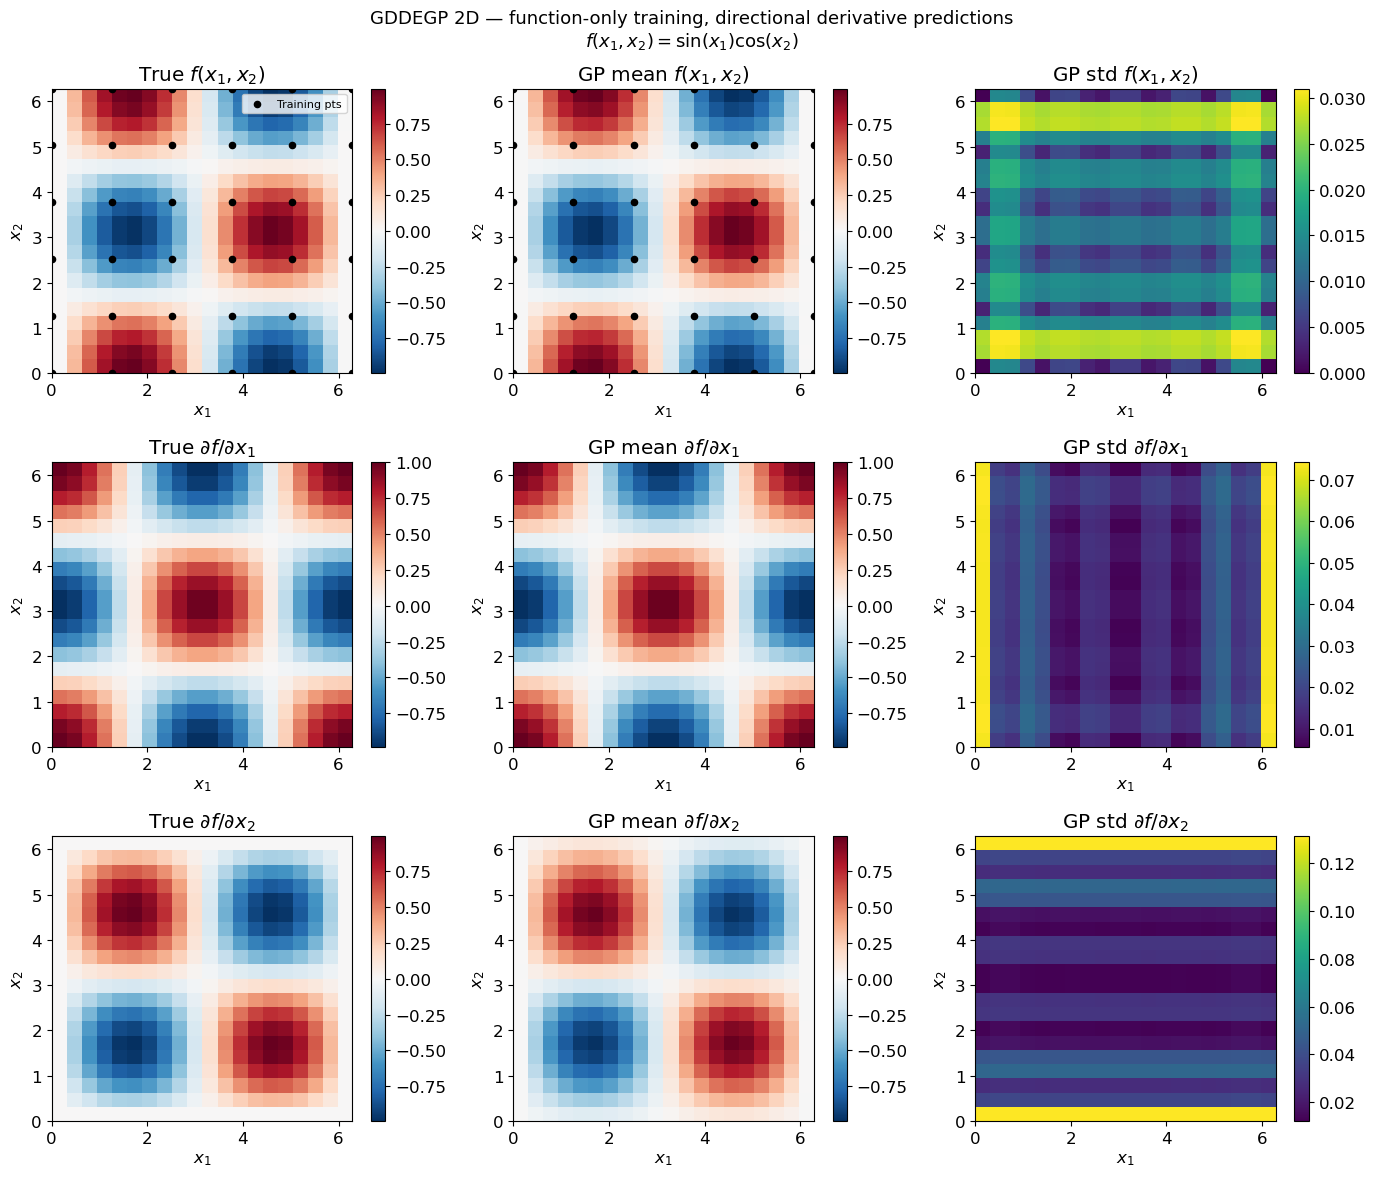

In [48]:
extent = [0, 2 * np.pi, 0, 2 * np.pi]
titles_row = [r"$f(x_1,x_2)$",
              r"$\partial f/\partial x_1$",
              r"$\partial f/\partial x_2$"]
trues = [f_true_grid,   dx1_true_grid,  dx2_true_grid]
means = [f_mean_grid,   dx1_mean_grid,  dx2_mean_grid]
stds  = [np.sqrt(np.abs(var[r, :])).reshape(shape2d) for r in range(3)]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
kw = dict(origin="lower", extent=extent, aspect="auto")

for row, (label, true, gp_mean, gp_std) in enumerate(
        zip(titles_row, trues, means, stds)):
    vmin, vmax = true.min(), true.max()

    im0 = axes[row, 0].imshow(true,    **kw, vmin=vmin, vmax=vmax, cmap="RdBu_r")
    axes[row, 0].set_title(f"True {label}")
    plt.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].imshow(gp_mean, **kw, vmin=vmin, vmax=vmax, cmap="RdBu_r")
    axes[row, 1].set_title(f"GP mean {label}")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(gp_std,  **kw, cmap="viridis")
    axes[row, 2].set_title(f"GP std {label}")
    plt.colorbar(im2, ax=axes[row, 2])

    for col in range(3):
        axes[row, col].set_xlabel("$x_1$")
        axes[row, col].set_ylabel("$x_2$")

for col in range(2):
    axes[0, col].scatter(X_train[:, 0], X_train[:, 1],
                         c="k", s=20, zorder=5, label="Training pts")
axes[0, 0].legend(fontsize=8, loc="upper right")

plt.suptitle(
    "GDDEGP 2D — function-only training, directional derivative predictions\n"
    r"$f(x_1,x_2) = \sin(x_1)\cos(x_2)$",
    fontsize=13,
)
plt.tight_layout()
plt.show()